In [86]:
from pathlib import Path
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

from matplotlib.ticker import PercentFormatter, FixedLocator, FixedFormatter

In [87]:
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))
LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

sns.set_theme(context="paper", style="ticks")

In [88]:
# get data from instances
data_path = Path("../data/anon_14_day_instances")
all_instances = list(data_path.glob("aggregate_instance_*.yaml"))

idx_to_n_farmers = {}
idx_to_n_ints = {}

for file in all_instances:
    instance = Instance.from_yaml(file)
    id = int(file.name[:-5].split("_")[-1])
    n_farmers = len(instance.farmers)
    n_intermediaries = len(instance.intermediaries)

    idx_to_n_farmers[id - 1] = n_farmers
    idx_to_n_ints[id - 1] = n_intermediaries

In [89]:
root = Path("../results/exp_4_heuristic")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"

data = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)

    metadata = payload["experiment_metadata"]

    if payload["completed"] is False:
        row = {
            "job_id": metadata["job_id"],
            "n_farmers": idx_to_n_farmers[metadata["job_id"] % 14],
            "n_intermediaries": idx_to_n_ints[metadata["job_id"] % 14],
            "strategy": "heuristic",
            "opt_gap": None,
            "time": None,
        }
    else:
        summary = payload["run"]["summary"]
        snapshot = summary["instance_snapshot"]
        farmers = snapshot["farmers"]
        intermediaries = snapshot["intermediaries"]

        row = {
            "job_id": metadata["job_id"],
            "n_farmers": len(farmers),
            "n_intermediaries": len(intermediaries),
            "opt_gap": summary["rel_gap"],
            "strategy": "heuristic",
            "time": summary["total_time"],
        }

    data.append(row)

df = pd.DataFrame(data)


In [90]:
root = Path("../results/exp_4_exact")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"

data_2 = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)

    metadata = payload["experiment_metadata"]

    if payload["completed"] is False:
        row = {
            "job_id": metadata["job_id"],
            "n_farmers": idx_to_n_farmers[metadata["job_id"] % 14],
            "n_intermediaries": idx_to_n_ints[metadata["job_id"] % 14],
            "opt_gap": None,
            "strategy": "exact",
            "time": None,
        }
    else:
        summary = payload["run"]["summary"]
        snapshot = summary["instance_snapshot"]
        farmers = snapshot["farmers"]
        intermediaries = snapshot["intermediaries"]

        row = {
            "job_id": metadata["job_id"],
            "n_farmers": len(farmers),
            "n_intermediaries": len(intermediaries),
            "opt_gap": summary["rel_gap"],
            "strategy": "exact",
            "time": summary["total_time"],
        }

    data_2.append(row)

df_2 = pd.DataFrame(data_2)


In [91]:
df_joint = pd.merge(df, df_2, how="inner", on=["job_id", "n_farmers", "n_intermediaries"])
df_joint["advantage"] = df_joint["time_y"] / df_joint["time_x"]

df_joint = df_joint.dropna()

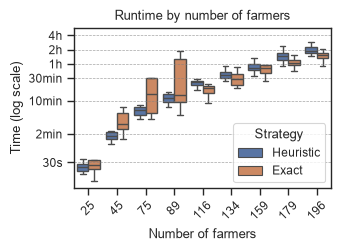

In [92]:
time_data_melted = df_joint.melt(
    id_vars=["n_farmers"], value_vars=["time_x", "time_y"], value_name="Time", var_name="Strategy"
)

time_data_filtered = (
    time_data_melted
    .query("n_farmers <= 196")
    .copy()
)

# seconds -> hours
time_data_filtered['Time'] = time_data_filtered['Time'] / 3600

label_mapping = {"time_x": "Heuristic", "time_y": "Exact"}
time_data_filtered["Strategy"] = time_data_filtered["Strategy"].map(label_mapping)

plt.figure(figsize=(3.5, 2.6))

ax = sns.boxplot(
    data=time_data_filtered,
    x='n_farmers',
    y='Time',
    showfliers=False,
    hue='Strategy'
)


# Logarithmic y-axis
ax.set_yscale('log')

# Tick positions are in HOURS
ticks = [
    30 / 3600,   # 30 sec
    2 / 60,      # 2 min
    10 / 60,     # 10 min
    30 / 60,     # 30 min
    1,
    2,           # 2 h
    4            # 4 h
]

tick_labels = [
    '30s',
    '2min',
    '10min',
    '30min',
    '1h',
    '2h',
    '4h'
]

# Horizontal grid lines
for tick in ticks:
    ax.axhline(
        y=tick,
        color='gray',
        linestyle='--',
        linewidth=0.5,
        alpha=0.7
    )

# Custom ticks
ax.yaxis.set_minor_locator(FixedLocator([]))
ax.yaxis.set_major_locator(FixedLocator(ticks))
ax.yaxis.set_major_formatter(FixedFormatter(tick_labels))

ax.set_title('Runtime by number of farmers')
ax.set_xlabel('Number of farmers')
ax.set_ylabel('Time (log scale)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/exp_4/runtime_farmers.png", bbox_inches='tight', dpi=300)
plt.show()

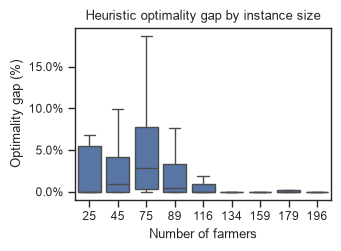

In [93]:
gap_data_filtered = df.query("n_farmers <= 196")

# Create the boxplot for opt_gap
plt.figure(figsize=(3.5, 2.6))
sns.boxplot(data=gap_data_filtered, x='n_farmers', y='opt_gap', showfliers=False)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Heuristic optimality gap by instance size')
plt.xlabel('Number of farmers')
plt.ylabel('Optimality gap (%)')
plt.tight_layout()
plt.savefig("../figures/exp_4/heur_opt_gaps.png", bbox_inches='tight', dpi=300)
plt.show()

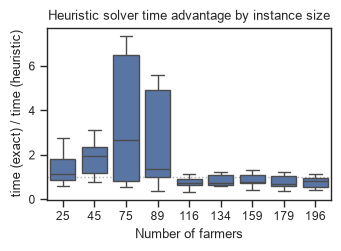

In [94]:
plt.figure(figsize=(3.5, 2.6))

sns.boxplot(
    df_joint.query("n_farmers <= 196"),
    x="n_farmers",
    y="advantage",
    showfliers=False
)

plt.axhline(1, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.ylabel("time (exact) / time (heuristic)")
plt.xlabel("Number of farmers")

plt.title('Heuristic solver time advantage by instance size')
plt.tight_layout()
plt.savefig("../figures/exp_4/heur_advantage.png", bbox_inches='tight', dpi=300)
plt.show()